## Regular solution model and phase diagram

#### <p style="text-align: right;"> &#9989; **put your name here** </p>

**Due by the end of today (3/30)**

---
**The regular solution model for the Gibbs free energy of mixing.** 

The regular solution model makes two assumptions:
* The entropy of mixing is given by ideal entropy of mixing (configurational entropy)
$$
\Delta S_\mathrm{mix} = -R \left [ x \ln x +(1−x) \ln(1−x) \right ]
$$
* The enthalpy of mixing follows a simple quadratic form
$$
\Delta H_\mathrm{mix}(x) = a_0 x (1 − x)
$$
where $a_0$ is a parameter describing the difference between the A–B interaction and the average of the A–A and B–B interactions.

The resulting Gibbs free energy of mixing is 
$$
\Delta G_\mathrm{mix}(x) = a_0 x (1 − x) + RT \left [ x \ln x +(1−x) \ln(1−x) \right ]
$$

If $a_0 >0$, the A and B atoms prefer to form A-A and B-B bonds instead of A-B bonds. As a consequence, there will be some compositions which are immiscible at lower temperatures. The critical temperature $T_c$ above which all compositions are miscible, is called the upper critical solution temperature (UCST),
$$
T_c = \frac{a_0}{2R},
$$

We will calculate the Gibbs free energy of the regular solution model for positive ($a_1: a_0>0$) and negative ($a_2: a_0<0$) departure from ideality. For the case of positive departure from ideality, we will calculate the boundary between the miscible and immiscible regions. This curve can be calculated analytically, but here we deduce it from the position of the minima in $\Delta G_{mix}$ as a function of temperature.

--content adopted from https://github.com/MatSciEd/Thermodynamics

* In the cell, make the function for calculating enthalpy, entropy, and  Gibbs free energy using regular solution model.

In [1]:
# Import NumPy numerical package
import numpy as np
import matplotlib.pyplot as plt


# Gas constant
R = 8.314 # J/mol/K

# Choice of temperature
T = 700 # K

# Parameters for the regular solution models
#   Model 1: positive departure from ideality, a1>0
#   Model 2: negative departure from ideality, a2<0
a1 = +20*1e3 # J/mol
a2 = -20*1e3 # J/mol


# Return the enthalpy for a regular solution
def get_H_rs(x, a):
    H_rs = a * x * (1-x)
    return H_rs

# Return the combinatorial entropy
def get_S_rs(x, R):
    S_rs = -R *(x * np.log(x) + (1-x) * np.log(1-x) )
    return S_rs

# Return the Gibbs free energy of mixing for a regular solution
def get_G_rs(H_rs, S_rs, T):
    G_rs = H_rs - T * S_rs
    return G_rs

### Calculate the enthalpy, entropy contribution, Gibbs free energy, and activities

In [3]:
# Array of compositions from 0 to 1
xv = np.linspace(0.0001,0.9999,401)

# Enthalpies of mixing
H1 = get_H_rs(xv, a1)
H2 = get_H_rs(xv, a2 )

# Ideal entropy of mixing
S = get_S_rs(xv, R)

# Gibbs free energy of mixing
G1 = get_G_rs(H1, S, T)
G2 = get_G_rs(H2, S, T)


Text(0.26, -8000, '$\\Delta G_{mix} = \\Delta H_{mix} - T\\Delta S_{mix}$')

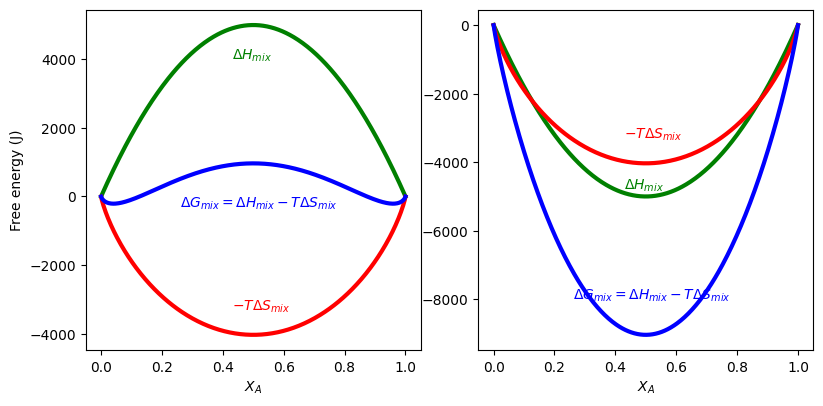

In [5]:
# make 2 subfigures to show Gibbs free energy
fig, ax = plt.subplots(1, 2, figsize=(8,4))
fig.tight_layout()

ax[0].plot(xv, H1, 'g-', linewidth=3.0)
ax[0].plot(xv, -T*S, 'r-', linewidth=3.0)
ax[0].plot(xv, G1, 'b-', linewidth=3.0)
ax[0].set_ylabel('Free energy (J)')
ax[0].set_xlabel('$X_A$')

ax[0].annotate(r'$\Delta H_{mix}$', xy=(0.43,4000), color='g', xycoords='data')
ax[0].annotate(r'$-T \Delta S_{mix}$', xy=(0.43,-3300), color='r', xycoords='data')
ax[0].annotate(r'$\Delta G_{mix} = \Delta H_{mix} - T\Delta S_{mix}$', xy=(0.26,-300), color='b', xycoords='data')



ax[1].plot(xv, H2, 'g-', linewidth=3.0)
ax[1].plot(xv, -T*S, 'r-', linewidth=3.0)
ax[1].plot(xv, G2, 'b-', linewidth=3.0)
ax[1].set_xlabel('$X_A$')

ax[1].annotate(r'$\Delta H_{mix}$', xy=(0.43,-4800), color='g', xycoords='data')
ax[1].annotate(r'$-T \Delta S_{mix}$', xy=(0.43,-3300), color='r', xycoords='data')
ax[1].annotate(r'$\Delta G_{mix} = \Delta H_{mix} - T\Delta S_{mix}$', xy=(0.26,-8000), color='b', xycoords='data')

**&#9989; Do This:**  What is the main difference between the features of $\Delta G_{mix}$ in $a_1$ and $a_2$ cases?

---
### Chemical activities

The partial molar Gibbs free energy:
$$\Delta \bar{G}_A = \Delta G_{mix} + X_B \frac{d \Delta G_{mix}}{d X_A } = RT \ln X_A + a X_B^2$$
and 
$$\Delta \bar{G}_A = RT \ln a_A.$$
Thus, we obtain the chemical activity as
$$\ln a_A = \ln X_A  + \frac{a}{RT} X_B^2 \Longrightarrow a_A = X_A \exp\bigg( \frac{aX_B^2}{RT} \bigg).$$

* Plot the chemical activities of $X_A$ and $X_B$ for the $a_1$ and $a_2$ cases.

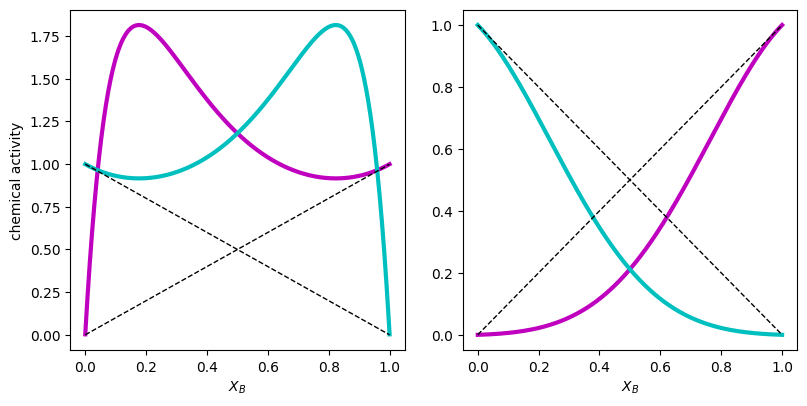

In [7]:
# chemical activities for a_1
a_A1 = xv * np.exp(a1*(1-xv)**2/R/T)
a_B1 = (1-xv) * np.exp(a1*xv**2/R/T)

# make 2 subfigures
fig, ax = plt.subplots(1, 2, figsize=(8,4))
fig.tight_layout()

ax[0].plot(xv, a_A1, 'm-', linewidth=3.0)
ax[0].plot(xv, a_B1, 'c-', linewidth=3.0)
ax[0].plot(xv, xv, 'k--', linewidth=1.0)
ax[0].plot(xv, 1-xv, 'k--', linewidth=1.0)
ax[0].set_ylabel('chemical activity')
ax[0].set_xlabel('$X_B$')

# chemical activities for a_2
a_A2 = xv * np.exp(a2*(1-xv)**2/R/T)
a_B2 = (1-xv) * np.exp(a2*xv**2/R/T)

ax[1].plot(xv, a_A2, 'm-', linewidth=3.0)
ax[1].plot(xv, a_B2, 'c-', linewidth=3.0)
ax[1].plot(xv, xv, 'k--', linewidth=1.0)
ax[1].plot(xv, 1-xv, 'k--', linewidth=1.0)
ax[1].set_xlabel('$X_B$')

plt.show()

**&#9989; Do This:** Explain chemical activities, Raoult's law, and Henry's law. 

**&#9989; Do This:** Explain how the of coefficient of $a$ affect chemical activities and what are the main difference between the $a_1$ in $a_2$ cases.

---
### Temperature dependent Gibbs free energy

Critical temperature is when temperature is above which there is all misciblity. 
$$T_c = \frac{a}{2R}.$$

* Plot Gibb's free energy at various temperature (ranging from below to above the critical temperature)

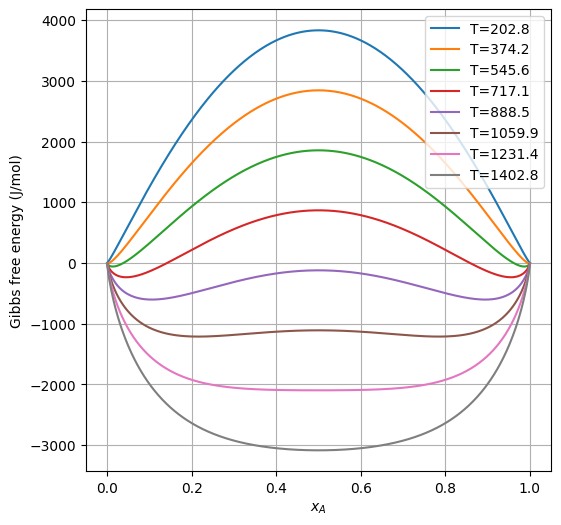

In [9]:
fig, ax = plt.subplots(figsize=(6,6))

Tc = a1/2/R
Tmin = Tc - 1000
Tmax = Tc + 200
tv = np.linspace(Tmin, Tmax, 8)

H = get_H_rs(xv, a1)
S = get_S_rs(xv, R)


for t in tv:
    G = get_G_rs(H, S, t)
    ax.plot(xv, G, label=f'T={t:0.1f}')

    
ax.set_xlabel('$x_{A}$')
ax.set_ylabel('Gibbs free energy (J/mol)')
ax.legend(prop={'size': 10}) 
ax.grid() 

plt.show()     

**&#9989; Do This:** Describe how Gibbs free energy function changes as temprature increases.

---
### Miscibility gap

The binodal points: the composition where the solution has its minima. The composition of the solution should remain at the binodal points.


**&#9989; Do This:** Estimate the equilibrium composition of the solution at T = 1000 K.

The local minima can be found as the roots of chemical potential:
$$\frac{\partial G}{\partial X} = 0.$$
Below provides the expression of $\mu=\partial G/\partial X$.

In [11]:
import sympy as sp

x, a_ex, R_ex, T_ex = sp.symbols('x a_ex R_ex T_ex')
G_ex = a_ex * x * (1-x) + R_ex * T_ex * (x*sp.log(x) + (1-x)*sp.log(1-x))
mu_ex = sp.diff(G_ex, x) 
mu_ex 



R_ex*T_ex*(log(x) - log(1 - x)) - a_ex*x + a_ex*(1 - x)

* Analytically solving the roots of chemical potential can be time consuming.
* Numerical search for the roots is more efficient.
* Roots are the points where the function values on their left and right sides are of different signs.  

In [25]:
from scipy.optimize import root_scalar
import numpy as np

# root_scalar is scipy built-in function for finding roots

def mu(x, a, R, T):
    # calculate mu and return the value
    return R*T*(np.log(x)-np.log(1-x)) - a*x + a * (1-x)
    
def root_finding(xs, mu, a, R, T, tol=1e-10):
    vals = mu(xs, a, R, T)
    roots = []

    for i in range(len(xs) - 1):
        fa = vals[i]
        fb = vals[i+1]

        if not np.isfinite(fa) or not np.isfinite(fb):
            continue

        if abs(fa) < tol:
            roots.append(xs[i])
        elif abs(fb) < tol:
            roots.append(xs[i+1])
        elif fa * fb < 0:
            sol = root_scalar(mu, args=(a, R, T),
                              bracket=[xs[i], xs[i+1]],
                              method='brentq')
            roots.append(sol.root)

    # remove duplicates
    roots = np.array(roots)
    if len(roots) == 0:
        return roots
    roots = np.unique(np.round(roots, 10))
    return roots

* Give a test of the function above. Run the cell below and check whether the found roots are correct.

[0.07007386 0.5        0.92992614]


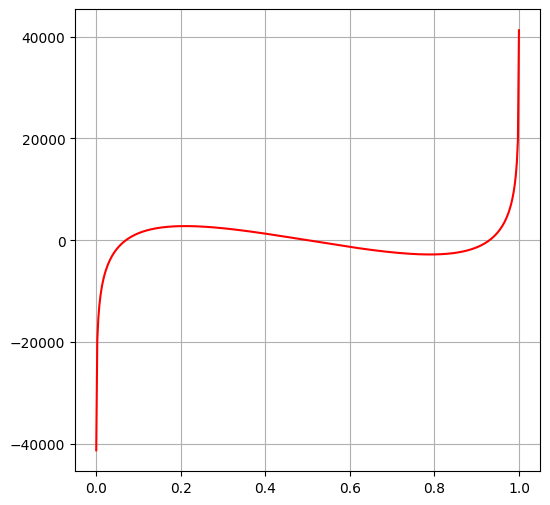

In [27]:
T = 800

mu_test = mu(xv, a1, R, T)
rt = root_finding(xv, mu, a1, R, T)
print(rt)

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(xv, mu_test,'r')
ax.grid(True)

plt.show()


**&#9989; Do This:** Are the roots close to those on the figure?

* Find the root of $\mu$ at various temperatures systematically.
* Plot the miscibility region (between binodal points)

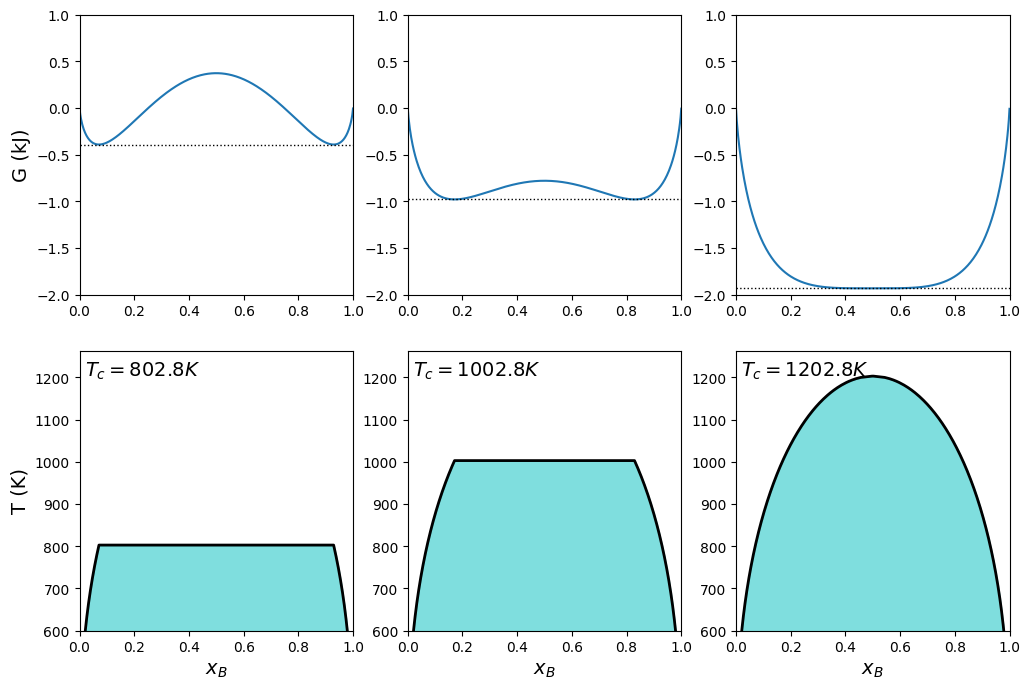

In [29]:
xs = np.linspace(1e-6, 1-1e-6, 500)

# create 2x3 subfigures
fig, ax = plt.subplots(2, 3, figsize=(12,8))
for i, axis in enumerate(ax.flat):
    axis.set_xlim(0, 1) 
    if i > 2:
        axis.set_ylim(600, Tc*1.05)
        axis.set_xlabel('$x_{B}$', fontsize=14)
    else:
        axis.set_ylim(-2,1)


# set up 3 temperatures
Num_T = 200
T_pd = np.array([Tc-400, Tc-200, Tc-0.01])

# enthalpy and entropy
H = get_H_rs(xv, a1)
S = get_S_rs(xv, R)


for i in range(len(T_pd)):
    t = T_pd[i]

    # plot Gibbs free energy
    G = get_G_rs(H, S, t)/1e3
    ax[0,i].plot(xv, G, label=(r'T='+ str(t)))
    ax[0,i].plot([xv[0], xv[-1]],[np.amin(G), np.amin(G)], "k:", lw = 1)
    

    # allocate array for storing the found roots
    tv = np.linspace(Tc/2, t, Num_T)
    xboundary = np.zeros(Num_T*2) 
    yboundary = np.zeros(Num_T*2) 

    cnt = 0
    for ti in tv:
        vals = mu(xs, a1, R, ti)
        r1 = root_finding(xs, mu, a1, R, ti, tol=1e-10)
        xboundary[cnt] = r1[0]
        yboundary[cnt] = ti
    
        xboundary[Num_T*2 - cnt -1] = r1[-1]
        yboundary[Num_T*2 - cnt -1] = ti
    
        cnt += 1

    ax[1,i].plot(xboundary, yboundary, 'k-', lw=2)
    ax[1,i].fill_between(xboundary, yboundary, color='c', alpha=0.5)
    ax[1,i].text(0.02, Tc, f'$T_c = {t:.1f}K$',fontsize=14)

ax[0,0].set_ylabel("G (kJ)", fontsize=14)
ax[1,0].set_ylabel("T (K)", fontsize=14)

plt.show()



---
### Metastable phase

The spinodal region is where the system can spontaneously separate into two phases. The spinodal points are determined by finding the roots of
$$\frac{\partial \mu}{\partial X} = \frac{\partial^2 G}{\partial X^2} = 0$$



In [31]:
# analytical expression
dmu_ex = sp.diff(mu_ex, x)
dmu_ex 

R_ex*T_ex*(1/(1 - x) + 1/x) - 2*a_ex

In [33]:
# create a function to calculate dmu
def dmu(x, a, R, T):
    return -2*a + R*T*(1/(1-x) + 1/x)    

* Below let's plot the spinodal region using the same method as in plotting miscibility gap.

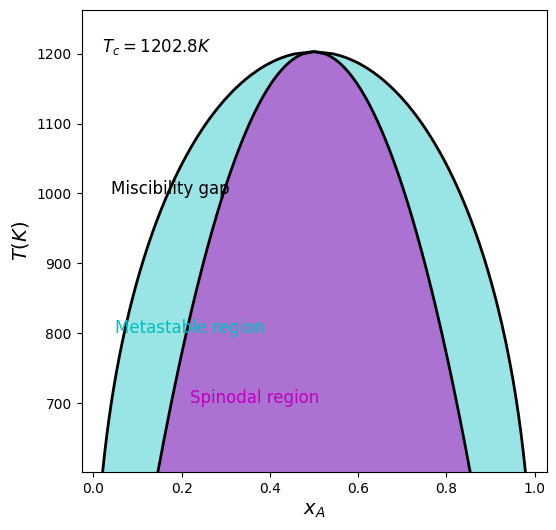

In [35]:
fig, ax = plt.subplots(figsize=(6,6))


t = T_pd[-1]

tv = np.linspace(Tc/2, t, Num_T)
xboundary = np.zeros(Num_T*2) 
sboundary = np.zeros(Num_T*2) 
yboundary = np.zeros(Num_T*2) 


cnt = 0
for ti in tv:

    # miscibility region
    vals = mu(xs, a1, R, ti)
    r1 = root_finding(xs, mu, a1, R, ti, tol=1e-10)
    xboundary[cnt] = r1[0]
    yboundary[cnt] = ti

    xboundary[Num_T*2 - cnt - 1] = r1[-1]
    yboundary[Num_T*2 - cnt - 1] = ti
    
    # spinodal region
    vals = dmu(xs, a1, R, ti)
    r2 = root_finding(xs, dmu, a1, R, ti, tol=1e-10)
    sboundary[cnt] = r2[0]
    sboundary[Num_T*2 - cnt - 1] = r2[-1]

    cnt += 1


# visualization
ax.plot(xboundary[:2*cnt], yboundary[:2*cnt], 'k', lw=2)
ax.fill_between(xboundary[:2*cnt], yboundary[:2*cnt], color='c', alpha=0.4)
ax.set_ylim(Tc/2, Tc*1.05)
ax.set_xlabel('$x_{A}$', fontsize=14)
ax.set_ylabel('$T (K)$', fontsize=14)


ax.plot(sboundary[:2*cnt], yboundary[:2*cnt], 'k', lw=2)
ax.fill_between(sboundary[:2*cnt], yboundary[:2*cnt], color='m', alpha=0.5)
ax.text(0.02, Tc, f'$T_c = {t:.1f}K$',fontsize=12) 

plt.annotate('Miscibility gap', xy=(0.04, 1000), color='k', xycoords='data',fontsize=12)
plt.annotate('Metastable region', xy=(0.05,800), color='c', xycoords='data',fontsize=12)
plt.annotate('Spinodal region', xy=(0.22,700), color='m', xycoords='data',fontsize=12)

plt.show()

**Please upload your completed file to**

https://www.dropbox.com/request/6mTfJJqt664XogvhYpq6